<a href="https://colab.research.google.com/github/yadhnyarpatil5/OOP-Library-Management-System/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib numpy openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [ ]:
np.random.seed(42)

dates = pd.date_range("2025-01-01","2025-06-30",freq="D")

products = ["Laptop","Phone","Tablet","Headphones","Monitor"]
categories = ["Electronics","Electronics","Electronics","Accessories","Accessories"]
customers = ["C001","C002","C003","C004","C005","C006","C007","C008"]
cities = ["Pune","Mumbai","Delhi","Bangalore","Hyderabad"]

data = []

for i in range(300):
    p = np.random.randint(0,len(products))
    qty = np.random.randint(1,6)
    price = np.random.randint(500,60000)

    data.append([
        np.random.choice(dates),
        products[p],
        categories[p],
        qty,
        price,
        np.random.choice(customers),
        np.random.choice(cities)
    ])

sales = pd.DataFrame(data,columns=[
    "Date",
    "Product",
    "Category",
    "Quantity",
    "Price",
    "CustomerID",
    "City"
])

sales["TotalSales"] = sales["Quantity"]*sales["Price"]

sales.to_csv("sales.csv",index=False)

print("sales.csv created successfully.")
sales.head()

sales.csv created successfully.


,Date,Product,Category,Quantity,Price,CustomerID,City,TotalSales
0,2025-04-17,Headphones,Accessories,5,38658,C008,Hyderabad,193290
1,2025-03-16,Monitor,Accessories,2,17350,C003,Hyderabad,34700
2,2025-02-22,Headphones,Accessories,3,2185,C002,Bangalore,6555
3,2025-06-10,Phone,Electronics,4,39688,C004,Mumbai,158752
4,2025-02-18,Monitor,Accessories,4,27980,C003,Delhi,111920


In [ ]:
sales = pd.read_csv("sales.csv")

sales.head()

,Date,Product,Category,Quantity,Price,CustomerID,City,TotalSales
0,2025-04-17,Headphones,Accessories,5,38658,C008,Hyderabad,193290
1,2025-03-16,Monitor,Accessories,2,17350,C003,Hyderabad,34700
2,2025-02-22,Headphones,Accessories,3,2185,C002,Bangalore,6555
3,2025-06-10,Phone,Electronics,4,39688,C004,Mumbai,158752
4,2025-02-18,Monitor,Accessories,4,27980,C003,Delhi,111920


In [ ]:
print("Dataset Information\n")

sales.info()

print("\nShape :",sales.shape)

print("\nMissing Values")

print(sales.isnull().sum())

print("\nDuplicate Rows :",sales.duplicated().sum())

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        300 non-null    object
 1   Product     300 non-null    object
 2   Category    300 non-null    object
 3   Quantity    300 non-null    int64 
 4   Price       300 non-null    int64 
 5   CustomerID  300 non-null    object
 6   City        300 non-null    object
 7   TotalSales  300 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 18.9+ KB

Shape : (300, 8)

Missing Values
Date          0
Product       0
Category      0
Quantity      0
Price         0
CustomerID    0
City          0
TotalSales    0
dtype: int64

Duplicate Rows : 0


In [ ]:
sales.drop_duplicates(inplace=True)

sales["Date"] = pd.to_datetime(sales["Date"])

sales.fillna(0,inplace=True)

print("Data Cleaned Successfully")

sales.head()

Data Cleaned Successfully


,Date,Product,Category,Quantity,Price,CustomerID,City,TotalSales
0,2025-04-17,Headphones,Accessories,5,38658,C008,Hyderabad,193290
1,2025-03-16,Monitor,Accessories,2,17350,C003,Hyderabad,34700
2,2025-02-22,Headphones,Accessories,3,2185,C002,Bangalore,6555
3,2025-06-10,Phone,Electronics,4,39688,C004,Mumbai,158752
4,2025-02-18,Monitor,Accessories,4,27980,C003,Delhi,111920


In [ ]:
category_sales = sales.groupby("Category")["TotalSales"].sum()
print("Total Sales by Category\n")
print(category_sales)

Total Sales by Category

Category
Accessories    11786650
Electronics    16182894
Name: TotalSales, dtype: int64


In [ ]:
product_sales = sales.groupby("Product")["TotalSales"].sum()
print("Top Selling Products\n")
print(product_sales.sort_values(ascending=False))

Top Selling Products

Product
Headphones    6129211
Laptop        5984215
Phone         5711713
Monitor       5657439
Tablet        4486966
Name: TotalSales, dtype: int64


In [ ]:
daily_sales = sales.groupby("Date")["TotalSales"].sum()
print(daily_sales.head())

Date
2025-01-01     21306
2025-01-02    185744
2025-01-03    248274
2025-01-04    161248
2025-01-05    208043
Name: TotalSales, dtype: int64


In [ ]:
average_order = sales["TotalSales"].mean()
print("Average Order Value")
print(round(average_order,2))

Average Order Value
93231.81


In [ ]:
peak_day = daily_sales.idxmax()
peak_sales = daily_sales.max()
print("Peak Sales Day :",peak_day)
print("Sales :",peak_sales)

Peak Sales Day : 2025-02-16 00:00:00
Sales : 993437


In [ ]:
sales["Month"] = sales["Date"].dt.to_period("M")
monthly_sales = sales.groupby("Month")["TotalSales"].sum()
growth = monthly_sales.pct_change()*100
print("Monthly Sales")
print(monthly_sales)
print("\nGrowth %")
print(growth)

Monthly Sales
Month
2025-01    4469820
2025-02    5255287
2025-03    4849331
2025-04    4878102
2025-05    4303899
2025-06    4213105
Freq: M, Name: TotalSales, dtype: int64

Growth %
Month
2025-01          NaN
2025-02    17.572676
2025-03    -7.724716
2025-04     0.593298
2025-05   -11.771033
2025-06    -2.109576
Freq: M, Name: TotalSales, dtype: float64


In [ ]:
customer_sales = sales.groupby("CustomerID")["TotalSales"].sum()
print(customer_sales)

CustomerID
C001    3499713
C002    2891843
C003    2440442
C004    4092342
C005    3745979
C006    3174145
C007    3398125
C008    4726955
Name: TotalSales, dtype: int64


In [ ]:
clv = sales.groupby("CustomerID")["TotalSales"].sum()
print("Customer Lifetime Value")
print(clv.sort_values(ascending=False))

Customer Lifetime Value
CustomerID
C008    4726955
C004    4092342
C005    3745979
C001    3499713
C007    3398125
C006    3174145
C002    2891843
C003    2440442
Name: TotalSales, dtype: int64


In [ ]:
forecast = daily_sales.rolling(window=7).mean()
print(forecast.tail())

Date
2025-06-26    110734.142857
2025-06-27    131369.857143
2025-06-28    145653.714286
2025-06-29    137423.000000
2025-06-30    117498.000000
Name: TotalSales, dtype: float64


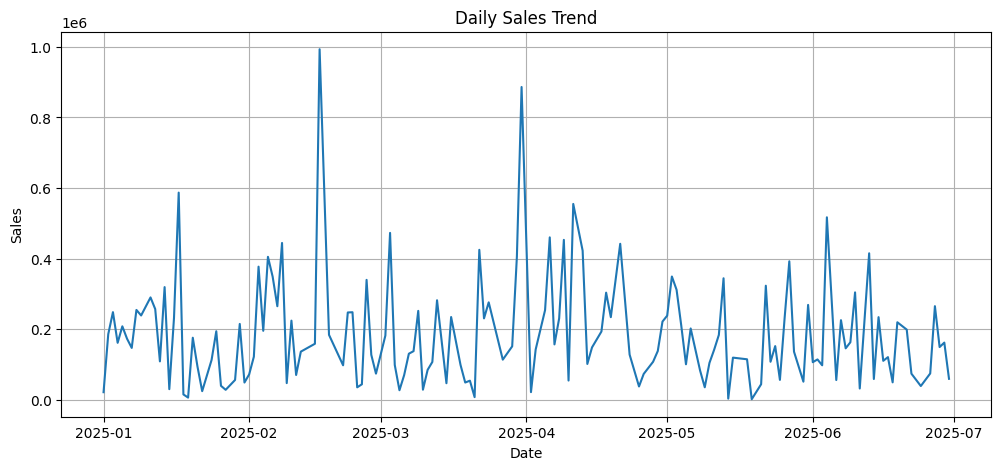

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales.index,daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

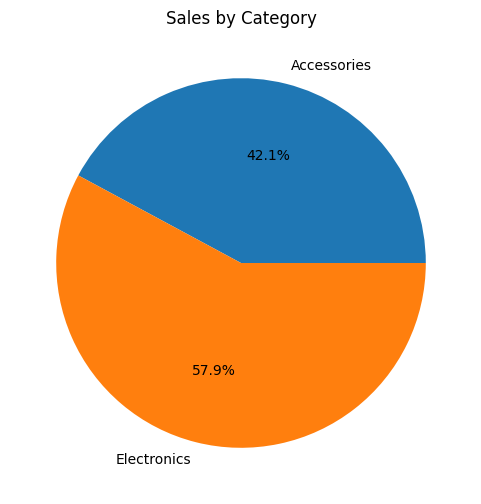

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct="%1.1f%%")
plt.title("Sales by Category")
plt.show()

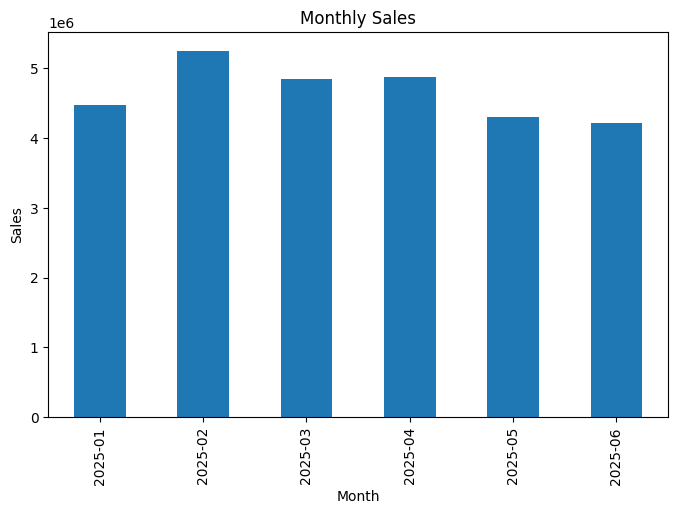

In [ ]:
monthly_sales.plot(kind="bar",figsize=(8,5))
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

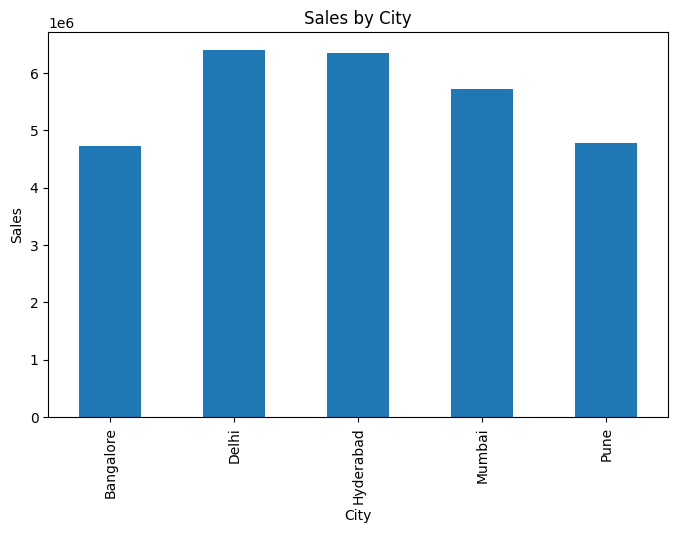

In [ ]:
city_sales = sales.groupby("City")["TotalSales"].sum()
city_sales.plot(kind="bar",figsize=(8,5))
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

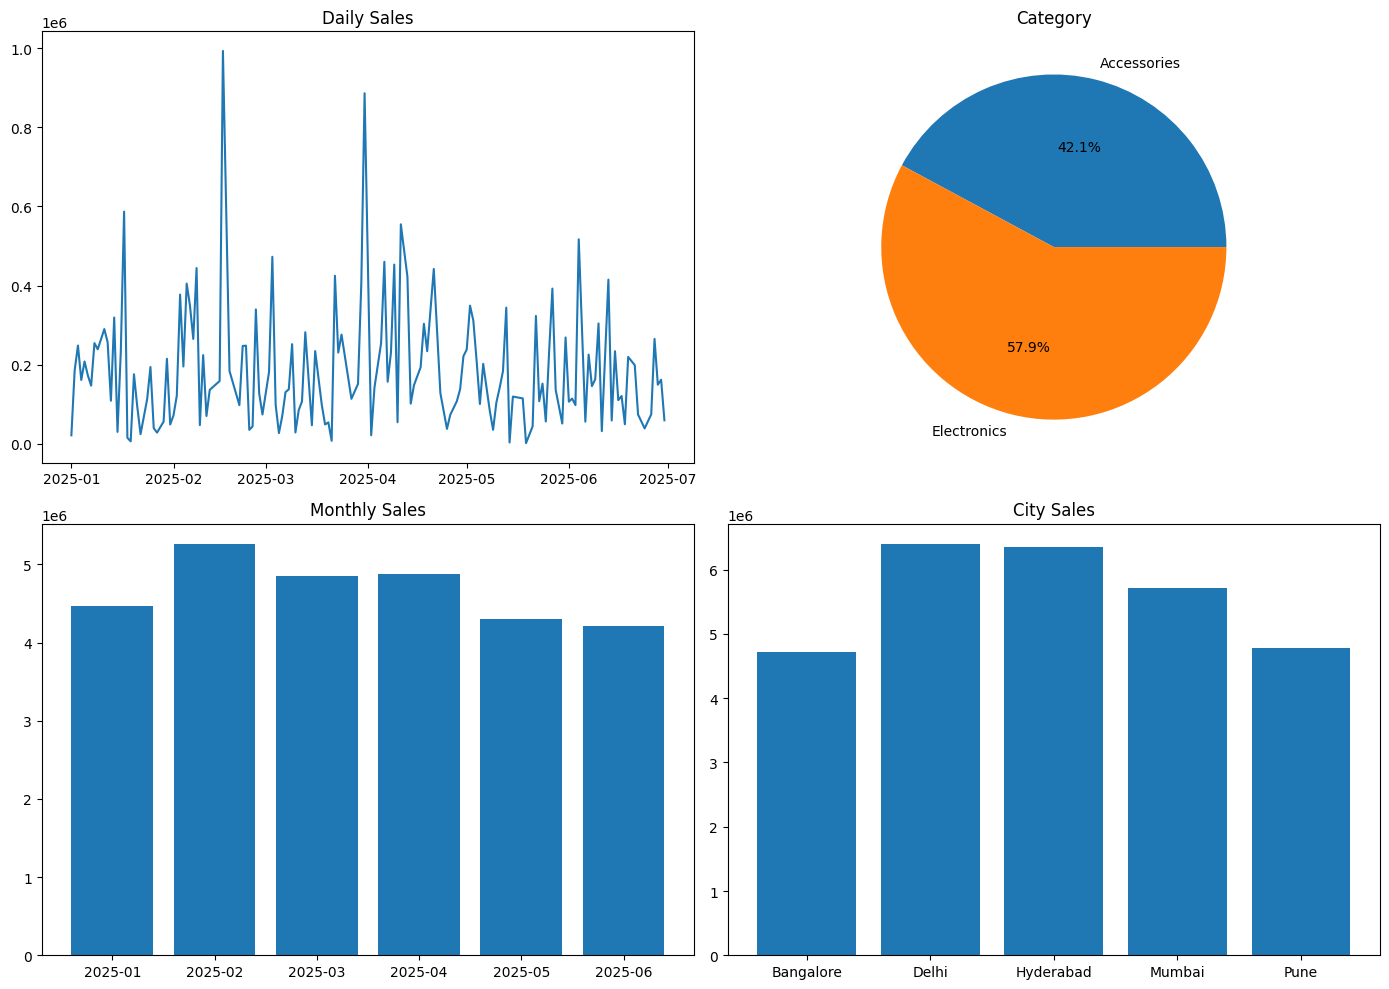

In [ ]:
fig,axs=plt.subplots(2,2,figsize=(14,10))

# Trend
axs[0,0].plot(daily_sales.index,daily_sales.values)
axs[0,0].set_title("Daily Sales")
# Pie
axs[0,1].pie(category_sales,
             labels=category_sales.index,
             autopct="%1.1f%%")
axs[0,1].set_title("Category")
# Monthly
axs[1,0].bar(monthly_sales.index.astype(str),monthly_sales.values)
axs[1,0].set_title("Monthly Sales")
# City
axs[1,1].bar(city_sales.index,city_sales.values)
axs[1,1].set_title("City Sales")
plt.tight_layout()
plt.show()

In [ ]:
category_sales.to_csv("category_sales.csv")
product_sales.to_csv("product_sales.csv")
monthly_sales.to_csv("monthly_sales.csv")
sales.to_excel("Cleaned_Sales.xlsx",index=False)
print("Files Exported Successfully")

Files Exported Successfully


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(daily_sales.index,daily_sales.values)
plt.title("Sales Trend")
plt.savefig("sales_trend.png")
plt.close()
print("Chart Saved")

Chart Saved


In [ ]:
print("="*50)
print("EXECUTIVE SUMMARY")
print("="*50)
print("Total Orders :",len(sales))
print("Total Revenue : ₹",round(sales["TotalSales"].sum(),2))
print("Average Order Value : ₹",round(sales["TotalSales"].mean(),2))
print("Top Product :",product_sales.idxmax())
print("Top Category :",category_sales.idxmax())
print("Top Customer :",clv.idxmax())
print("Top City :",city_sales.idxmax())
print("="*50)

EXECUTIVE SUMMARY
Total Orders : 300
Total Revenue : ₹ 27969544
Average Order Value : ₹ 93231.81
Top Product : Headphones
Top Category : Electronics
Top Customer : C008
Top City : Delhi
